<a href="https://colab.research.google.com/github/BraianRicoIUD/Modulo2-Actividad-didactica2-m3/blob/main/Braian_Maria_Santiago_problemaBancario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install simpy pandas numpy


✅ SIMULACIÓN COMPLETADA: REPORTE DE RESULTADOS

▶ PUNTO 1: DESEMPEÑO DE CAJEROS (Modelo Mixto)
  cajero  servicio
Cajero_3  2.937680
Cajero_2  3.068268
Cajero_1  3.176644

▶ PUNTO 2: VOLUMEN PROMEDIO DE USUARIOS (Jornada 8h)


,tipo,perfil,promedio_clientes
0,pago,Lento,18.8
1,pago,Muy lento,22.4
2,pago,Normal,13.2
3,pago,Rápido,6.7
4,retiro,Lento,23.1
5,retiro,Muy lento,30.2
6,retiro,Normal,58.6
7,retiro,Rápido,33.2



▶ PUNTO 3: MATRIZ DE CLIENTES POR RÉPLICA


,replica,pago_Lento,pago_Muy lento,pago_Normal,pago_Rápido,retiro_Lento,retiro_Muy lento,retiro_Normal,retiro_Rápido
0,1,19,28,13,6,23,31,65,33
1,2,23,23,18,8,29,27,52,24
2,3,23,24,11,7,25,27,57,34
3,4,12,27,11,9,26,23,58,29
4,5,17,17,17,4,19,24,59,33
5,6,20,22,13,9,21,30,70,50
6,7,14,17,14,4,34,28,60,35
7,8,16,23,17,6,26,36,66,30
8,9,17,22,11,11,19,35,68,28
9,10,25,18,11,9,25,29,61,39



▶ PUNTO 4: ANÁLISIS DE CUELLOS DE BOTELLA (3 CAJAS MIXTAS)
  - Factor de Utilización (ρ): 43.82%
  - Tiempo de espera general (Wq): 0.45 min

▶ PUNTO 5: COMPARATIVA DE ARQUITECTURAS
  1. Fila Mixta (3 Cajeros): 0.45 min
  2. Esp. A (2 Retiros / 1 Pago): 2.79 min  <-- Colapso en canal de pagos
  3. Esp. B (1 Retiro / 2 Pagos): 4.57 min  <-- Colapso en canal de retiros


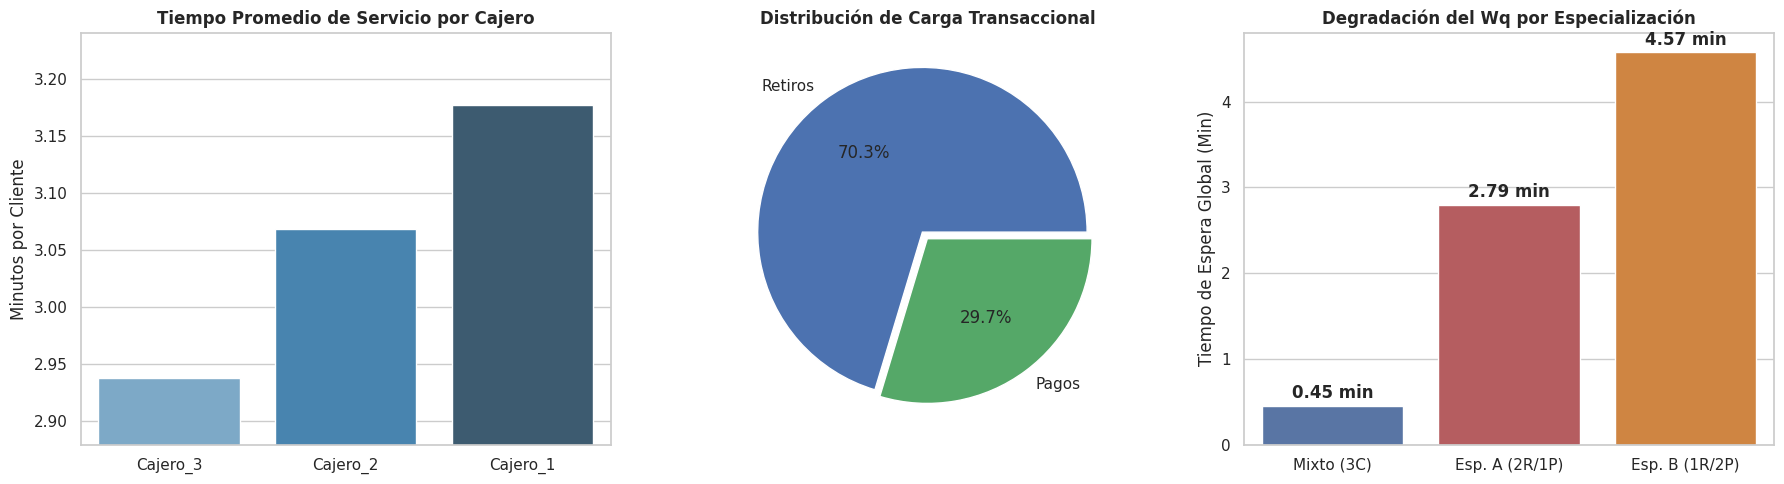

In [ ]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ==========================================
# 1. CONFIGURACIÓN DEL SISTEMA
# ==========================================
np.random.seed(42) # Semilla para reproducibilidad exacta
HORAS_OPERACION = 8
TIEMPO_SIMULACION = HORAS_OPERACION * 60
NUM_CAJEROS = 3
NUM_REPLICAS = 20

CONFIG_BANCO = {
    'retiro': {
        'prob_global': 0.70,
        'perfiles': ['Rápido', 'Normal', 'Lento', 'Muy lento'],
        'prob_perfil': [0.23, 0.40, 0.17, 0.20],
        'media_servicio': [1, 2, 3, 4],
        'media_llegada': [1, 2, 3, 3]
    },
    'pago': {
        'prob_global': 0.30,
        'perfiles': ['Rápido', 'Normal', 'Lento', 'Muy lento'],
        'prob_perfil': [0.10, 0.20, 0.30, 0.40],
        'media_servicio': [3, 3, 5, 7],
        'media_llegada': [1, 2, 3, 4]
    }
}

# ==========================================
# 2. DEFINICIÓN DE ARQUITECTURAS DE COLAS
# ==========================================
class BancoMixto:
    def __init__(self, env):
        self.env = env
        self.cola = simpy.Store(env)
        for i in range(NUM_CAJEROS):
            env.process(self.operar('Cajero_'+str(i+1), self.cola))

    def operar(self, id_cajero, cola):
        while True:
            cliente = yield cola.get()
            inicio = self.env.now
            yield self.env.timeout(np.random.exponential(CONFIG_BANCO[cliente['tipo']]['media_servicio'][cliente['idx']]))
            cliente.update({'cajero': id_cajero, 'inicio': inicio, 'espera': inicio - cliente['llegada'], 'servicio': self.env.now - inicio})
            registro_actual.append(cliente)

class BancoEspecializado:
    def __init__(self, env, cajas_retiro, cajas_pago):
        self.env = env
        self.cola_ret = simpy.Store(env)
        self.cola_pag = simpy.Store(env)
        for i in range(cajas_retiro): env.process(self.operar('Caja_Ret_'+str(i+1), self.cola_ret))
        for i in range(cajas_pago): env.process(self.operar('Caja_Pag_'+str(i+1), self.cola_pag))

    def operar(self, id_cajero, cola):
        while True:
            cliente = yield cola.get()
            inicio = self.env.now
            yield self.env.timeout(np.random.exponential(CONFIG_BANCO[cliente['tipo']]['media_servicio'][cliente['idx']]))
            cliente.update({'espera': inicio - cliente['llegada']})
            registro_actual.append(cliente)

def generador_clientes(env, banco, especializado=False):
    id_cliente = 1
    while True:
        tipo = 'retiro' if np.random.random() < CONFIG_BANCO['retiro']['prob_global'] else 'pago'
        idx = np.random.choice(range(4), p=CONFIG_BANCO[tipo]['prob_perfil'])
        cliente = {'id': id_cliente, 'tipo': tipo, 'perfil': CONFIG_BANCO[tipo]['perfiles'][idx], 'idx': idx, 'llegada': env.now}

        if especializado:
            banco.cola_ret.put(cliente) if tipo == 'retiro' else banco.cola_pag.put(cliente)
        else:
            banco.cola.put(cliente)

        yield env.timeout(np.random.exponential(CONFIG_BANCO[tipo]['media_llegada'][idx]))
        id_cliente += 1

# ==========================================
# 3. MOTOR DE SIMULACIÓN Y RECOLECCIÓN DE DATOS
# ==========================================
def correr_simulacion(ArquitecturaClase, kwargs_banco, especializado=False):
    global registro_actual
    historial = []
    for rep in range(1, NUM_REPLICAS + 1):
        registro_actual = []
        env = simpy.Environment()
        banco = ArquitecturaClase(env, **kwargs_banco)
        env.process(generador_clientes(env, banco, especializado))
        env.run(until=TIEMPO_SIMULACION)
        for reg in registro_actual: reg['replica'] = rep
        historial.extend(registro_actual)
    return pd.DataFrame(historial)

# Ejecutamos los 3 escenarios
df_mixto = correr_simulacion(BancoMixto, {})
df_esp_A = correr_simulacion(BancoEspecializado, {'cajas_retiro': 2, 'cajas_pago': 1}, especializado=True)
df_esp_B = correr_simulacion(BancoEspecializado, {'cajas_retiro': 1, 'cajas_pago': 2}, especializado=True)

# ==========================================
# 4. REPORTE EN CASCADA (Outputs)
# ==========================================
print("\n" + "="*70 + "\n✅ SIMULACIÓN COMPLETADA: REPORTE DE RESULTADOS\n" + "="*70)

# PUNTO 1
print("\n▶ PUNTO 1: DESEMPEÑO DE CAJEROS (Modelo Mixto)")
t_cajeros = df_mixto.groupby('cajero')['servicio'].mean().reset_index().sort_values('servicio')
print(t_cajeros.to_string(index=False))

# PUNTO 2
print("\n▶ PUNTO 2: VOLUMEN PROMEDIO DE USUARIOS (Jornada 8h)")
promedios = df_mixto.groupby(['replica', 'tipo', 'perfil']).size().reset_index(name='cant')
promedios = promedios.groupby(['tipo', 'perfil'])['cant'].mean().reset_index(name='promedio_clientes').round(1)
display(promedios)

# PUNTO 3
print("\n▶ PUNTO 3: MATRIZ DE CLIENTES POR RÉPLICA")
matriz = pd.pivot_table(df_mixto, values='id', index='replica', columns=['tipo', 'perfil'], aggfunc='count', fill_value=0)
matriz.columns = [f"{t}_{p}" for t, p in matriz.columns]
display(matriz.reset_index())

# PUNTO 4
print("\n▶ PUNTO 4: ANÁLISIS DE CUELLOS DE BOTELLA (3 CAJAS MIXTAS)")
wq_mixto = df_mixto['espera'].mean()
rho_mixto = (df_mixto.groupby('replica')['servicio'].sum().mean() / (3 * 480)) * 100
print(f"  - Factor de Utilización (ρ): {rho_mixto:.2f}%")
print(f"  - Tiempo de espera general (Wq): {wq_mixto:.2f} min")

# PUNTO 5
print("\n▶ PUNTO 5: COMPARATIVA DE ARQUITECTURAS")
wq_A = df_esp_A['espera'].mean()
wq_B = df_esp_B['espera'].mean()
print(f"  1. Fila Mixta (3 Cajeros): {wq_mixto:.2f} min")
print(f"  2. Esp. A (2 Retiros / 1 Pago): {wq_A:.2f} min  <-- Colapso en canal de pagos")
print(f"  3. Esp. B (1 Retiro / 2 Pagos): {wq_B:.2f} min  <-- Colapso en canal de retiros")

# ==========================================
# 5. RENDERIZADO DE GRÁFICOS (Automático y sin warnings)
# ==========================================
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Cajeros (Datos dinámicos)
sns.barplot(data=t_cajeros, x='cajero', y='servicio', ax=axes[0], hue='cajero', palette="Blues_d", legend=False)
axes[0].set_title('Tiempo Promedio de Servicio por Cajero', fontweight='bold')
axes[0].set_ylabel('Minutos por Cliente')
axes[0].set_xlabel('')
axes[0].set_ylim(t_cajeros['servicio'].min() * 0.98, t_cajeros['servicio'].max() * 1.02)

# Gráfico 2: Proporción
trafico = df_mixto['tipo'].value_counts()
axes[1].pie(trafico, labels=[f"{i.capitalize()}s" for i in trafico.index], autopct='%1.1f%%', colors=['#4C72B0', '#55A868'], explode=(0.05, 0))
axes[1].set_title('Distribución de Carga Transaccional', fontweight='bold')

# Gráfico 3: Comparativa de Wq (3 barras dinámicas)
escenarios = ['Mixto (3C)', 'Esp. A (2R/1P)', 'Esp. B (1R/2P)']
tiempos_wq = [wq_mixto, wq_A, wq_B]
sns.barplot(x=escenarios, y=tiempos_wq, ax=axes[2], hue=escenarios, palette=['#4C72B0', '#C44E52', '#E6842A'], legend=False)
axes[2].set_title('Degradación del Wq por Especialización', fontweight='bold')
axes[2].set_ylabel('Tiempo de Espera Global (Min)')
for i, v in enumerate(tiempos_wq): axes[2].text(i, v + (max(tiempos_wq)*0.02), f"{v:.2f} min", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()